In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def plot_cic_frequency_response(R=8, M=1, N=3, fs_in=1000.0):
    """
    Plots the frequency response of a CIC Decimation Filter.
    
    Parameters:
    -----------
    R : int - Decimation factor
    M : int - Differential delay (usually 1 or 2)
    N : int - Number of stages
    fs_in : float - Input sampling frequency in Hz
    """
    # Calculate output sampling rate
    fs_out = fs_in / R
    
    # Generate frequency array up to the input Nyquist frequency
    f = np.linspace(1e-5, fs_in / 2, 5000)
    
    # Normalized frequencies for formula calculation
    omega_in = 2 * np.pi * f / fs_in
    
    # Calculate the frequency response H(e^jw)
    # Using the Dirichlet kernel/sinc-like magnitude response formula
    numerator = np.sin(omega_in * R * M / 2)
    denominator = np.sin(omega_in / 2)
    
    # Avoid division by zero anomalies and compute magnitude
    magnitude = np.abs(numerator / denominator) ** N
    
    # Normalize DC gain to 0 dB. (The raw DC gain of a CIC is (R*M)^N)
    dc_gain = (R * M) ** N
    magnitude_db = 20 * np.log10(magnitude / dc_gain)
    
    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(f, magnitude_db, label=f'CIC Response (R={R}, M={M}, N={N})', color='blue', linewidth=2)
    
    # Highlight the new Output Nyquist frequency boundary
    plt.axvline(fs_out / 2, color='red', linestyle='--', alpha=0.7, 
                label=f'Output Nyquist Bound ({fs_out/2:.1f} Hz)')
    
    # Highlight potential alias bands (around multiples of fs_out)
    for i in range(1, int(R/2) + 1):
        null_freq = i * fs_out
        if null_freq < fs_in / 2:
            plt.axvline(null_freq, color='green', linestyle=':', alpha=0.5)
            # Shade the alias band that folds back into the passband
            plt.axvspan(null_freq - (fs_out/2), min(null_freq + (fs_out/2), fs_in/2), 
                        color='gray', alpha=0.1, label='Aliasing Zone' if i==1 else "")

    plt.title(f'CIC Decimation Filter Frequency Response\n(Input Rate: {fs_in} Hz $\\rightarrow$ Output Rate: {fs_out:.2f} Hz)')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude (dB)')
    plt.ylim([-100, 5])
    plt.grid(True, which='both', linestyle='-', alpha=0.4)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

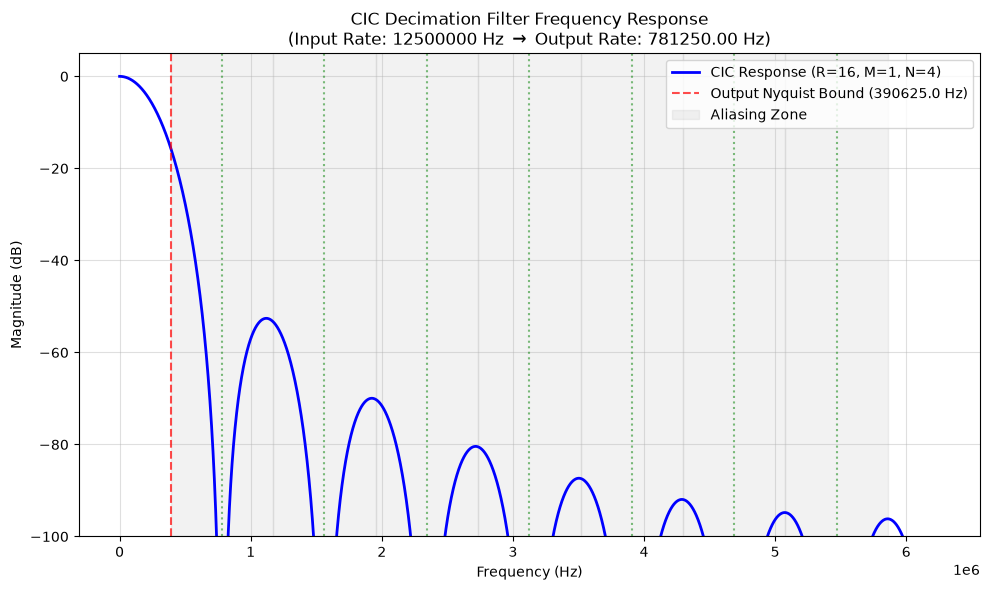

In [19]:
plot_cic_frequency_response(
    R=16,       # Decimation factor
    M=1,        # Differential delay
    N=4,        # Number of stages (increases attenuation & passband droop)
    fs_in=12500000 # Input sampling rate in Hz (e.g., 32 kHz input down to 1 kHz output)
)

In [20]:
def plot_cic_frequency_response_with_decimation(R=8, M=1, N=3, fs_in=1000.0):
    """
    Plots the frequency response of a CIC Decimation Filter both pre-decimation 
    and post-decimation (showing alias folding into the output baseband).
    
    Parameters:
    -----------
    R : int - Decimation factor
    M : int - Differential delay (usually 1 or 2)
    N : int - Number of stages
    fs_in : float - Input sampling frequency in Hz
    """
    # Calculate output sampling rate and Nyquist limits
    fs_out = fs_in / R
    nyq_out = fs_out / 2.0
    dc_gain = (R * M) ** N
    
    # =========================================================================
    # 1. PRE-DECIMATION RESPONSE (0 to fs_in / 2)
    # =========================================================================
    f_in = np.linspace(1e-5, fs_in / 2, 5000)
    omega_in = 2 * np.pi * f_in / fs_in
    
    numerator_in = np.sin(omega_in * R * M / 2)
    denominator_in = np.sin(omega_in / 2)
    magnitude_in = np.abs(numerator_in / denominator_in) ** N
    mag_in_db = 20 * np.log10(magnitude_in / dc_gain)
    
    # =========================================================================
    # 2. POST-DECIMATION FOLDED RESPONSE (0 to fs_out / 2)
    # =========================================================================
    f_out = np.linspace(1e-5, nyq_out, 2000)
    H_folded = np.zeros(len(f_out), dtype=complex)
    
    # Accumulate all R frequency-shifted aliases folding into baseband
    for k in range(R):
        f_shifted = f_out + (k * fs_out)
        omega_shifted = 2 * np.pi * f_shifted / fs_in
        
        # CIC Transfer Function H(e^jw) = ( (1 - e^(-j*w*R*M)) / (1 - e^(-j*w)) )^N
        num_complex = 1 - np.exp(-1j * omega_shifted * R * M)
        den_complex = 1 - np.exp(-1j * omega_shifted)
        
        # Avoid zero division at DC (k=0)
        H_k = np.where(np.abs(den_complex) < 1e-12, (R * M), num_complex / den_complex) ** N
        H_folded += H_k
        
    # Scale by 1/R for downsampling power normalization
    H_folded = H_folded / R
    mag_folded_db = 20 * np.log10(np.abs(H_folded) / (dc_gain / R) + 1e-12)

    # =========================================================================
    # 3. PLOTTING
    # =========================================================================
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
    
    # Subplot 1: Pre-Decimation Spectrum
    ax1.plot(f_in, mag_in_db, label=f'CIC Response (R={R}, M={M}, N={N})', color='blue', linewidth=2)
    ax1.axvline(nyq_out, color='red', linestyle='--', alpha=0.7, 
                label=f'Output Nyquist Bound ({nyq_out:.1f} Hz)')
    
    for i in range(1, int(R/2) + 1):
        null_freq = i * fs_out
        if null_freq < fs_in / 2:
            ax1.axvline(null_freq, color='green', linestyle=':', alpha=0.5)
            ax1.axvspan(null_freq - nyq_out, min(null_freq + nyq_out, fs_in / 2), 
                        color='gray', alpha=0.1, label='Aliasing Zone' if i == 1 else "")

    ax1.set_title(f'1. Pre-Decimation Frequency Response (Input Sampling Rate: {fs_in:.2f} Hz)')
    ax1.set_xlabel('Frequency (Hz)')
    ax1.set_ylabel('Magnitude (dB)')
    ax1.set_ylim([-100, 5])
    ax1.grid(True, which='both', linestyle='-', alpha=0.4)
    ax1.legend(loc='upper right')

    # Subplot 2: Post-Decimation Folded Spectrum
    ax2.plot(f_out, mag_folded_db, color='purple', linewidth=2, 
             label=f'Decimated Baseband Spectrum (fs_out = {fs_out:.2f} Hz)')
    ax2.set_title('2. Post-Decimation Baseband Spectrum (Includes Alias Folding Effects)')
    ax2.set_xlabel('Baseband Frequency (Hz)')
    ax2.set_ylabel('Magnitude (dB)')
    ax2.set_ylim([-100, 5])
    ax2.set_xlim([0, nyq_out])
    ax2.grid(True, which='both', linestyle='-', alpha=0.4)
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

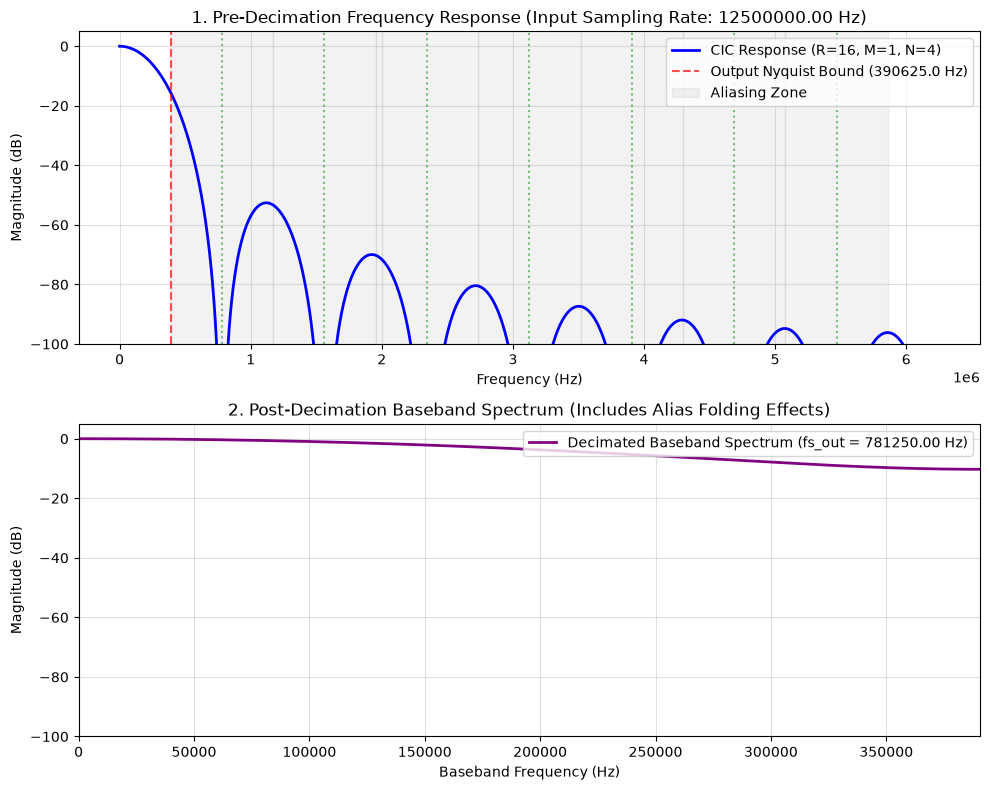

In [21]:
plot_cic_frequency_response_with_decimation(R=16, M=1, N=4, fs_in=12500000.0)